In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib
warnings.filterwarnings('ignore')

In [2]:
d1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_p1.csv')

d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    35040 non-null  object 
 1   Kwh     35040 non-null  float64
 2   LaCR    35040 non-null  float64
 3   LeCR    35040 non-null  float64
 4   co2     35040 non-null  float64
 5   LaF     35040 non-null  float64
 6   LeF     35040 non-null  float64
dtypes: float64(6), object(1)
memory usage: 1.9+ MB


In [3]:
d1.head()

,date,Kwh,LaCR,LeCR,co2,LaF,LeF
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0


In [4]:
d1['cat'] = np.where(d1['Kwh'] > 4.1, 1, 0)

In [5]:
d1['date'] = pd.to_datetime(d1['date'], format='%d/%m/%Y %H:%M')
d1.set_index('date', inplace=True)

In [6]:
d1.head()

,Kwh,LaCR,LeCR,co2,LaF,LeF,cat
date,,,,,,,
2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,0
2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,0
2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,0
2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,0
2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,0


Text(0.5, 1.0, '시계열 데이터')

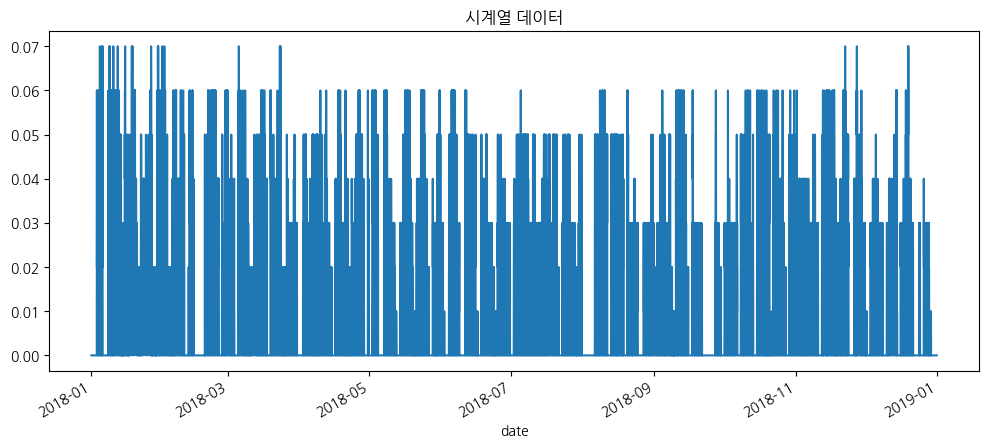

In [7]:
d1['co2'].plot(figsize=(12, 5))
plt.title('시계열 데이터')

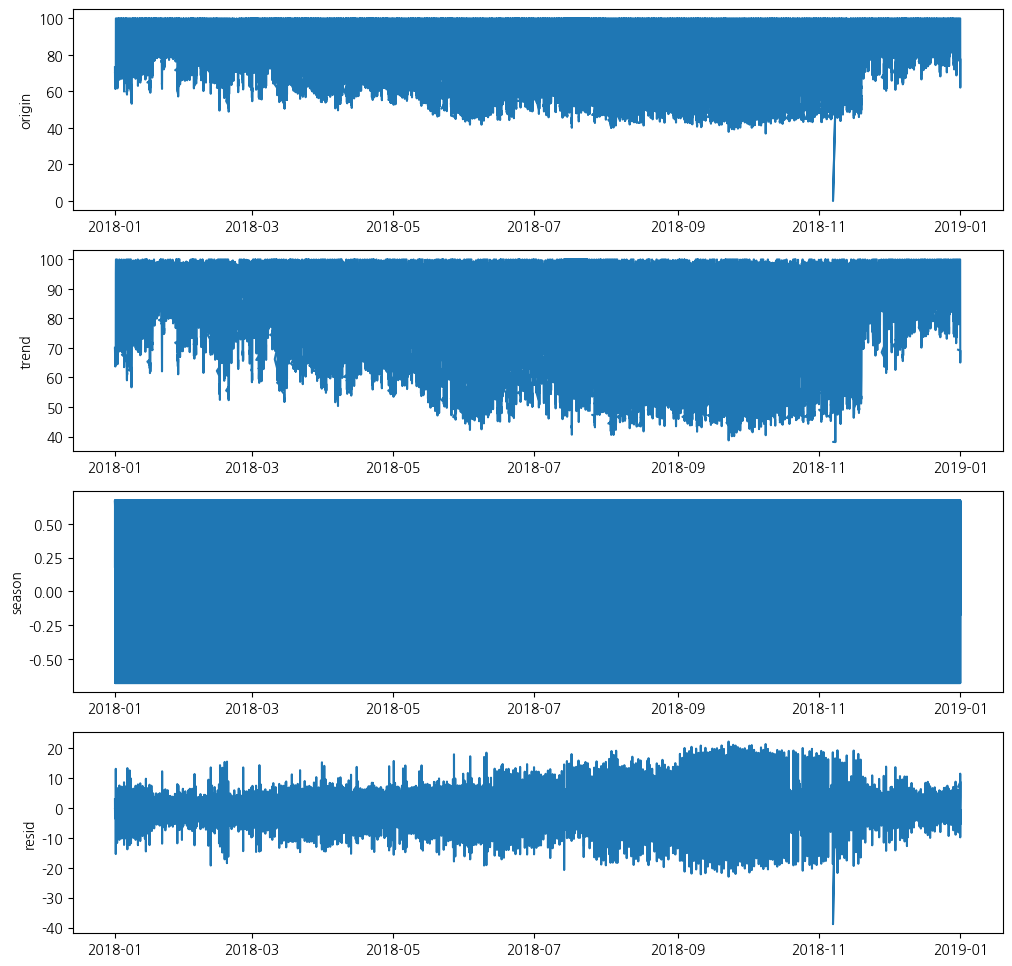

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

fitted = seasonal_decompose(d1['LaF'], period=4, extrapolate_trend='freq')
resid = fitted.resid
seasonal = fitted.seasonal
trend = fitted.trend

t_list = ['origin', 'trend', 'season', 'resid']
d_list = [d1['LaF'], trend, seasonal, resid]

fit, ax = plt.subplots(4, 1, figsize=(12, 12))

for t, d, ax in zip(t_list, d_list, ax.flatten()):
    ax.plot(d)
    ax.set_ylabel(t)
plt.show()

- 추세: 상승(이분산 경향), 계절성 주기성 확연, 잔차 일정함(0을 기준으로 분포)

In [9]:
from scipy.stats import zscore

z_e = resid[np.abs(zscore(resid)) > 3].to_frame().reset_index()

z_e

,date,resid
0,2018-01-01 08:45:00,-15.369698
1,2018-01-01 09:00:00,13.176968
2,2018-01-01 22:30:00,-11.673435
3,2018-01-02 22:30:00,-10.615935
4,2018-01-03 22:30:00,-10.155935
...,...,...
677,2018-12-29 22:00:00,8.876968
678,2018-12-29 22:15:00,-8.893835
679,2018-12-31 22:00:00,11.551968
680,2018-12-31 22:15:00,-9.780085


In [10]:
q1 = resid.quantile(0.25)
q3 = resid.quantile(0.75)
iqr = q3 - q1
up = q3 + (1.5*iqr)
down = q1 - (1.5*iqr)

q_er = resid[(resid > up)|(resid < down)].to_frame().reset_index()

display(q_er)


,date,resid
0,2018-01-01 08:45:00,-15.369698
1,2018-01-01 09:00:00,13.176968
2,2018-01-01 09:15:00,4.613665
3,2018-01-01 22:00:00,5.438218
4,2018-01-01 22:15:00,6.724915
...,...,...
4001,2018-12-31 22:15:00,-9.780085
4002,2018-12-31 22:30:00,-5.128435
4003,2018-12-31 23:00:00,-5.423032
4004,2018-12-31 23:45:00,8.822427


In [11]:
# 겹치는 중복값
mg = pd.merge(z_e, q_er, how='inner', on='date')

display(mg)


,date,resid_x,resid_y
0,2018-01-01 08:45:00,-15.369698,-15.369698
1,2018-01-01 09:00:00,13.176968,13.176968
2,2018-01-01 22:30:00,-11.673435,-11.673435
3,2018-01-02 22:30:00,-10.615935,-10.615935
4,2018-01-03 22:30:00,-10.155935,-10.155935
...,...,...,...
677,2018-12-29 22:00:00,8.876968,8.876968
678,2018-12-29 22:15:00,-8.893835,-8.893835
679,2018-12-31 22:00:00,11.551968,11.551968
680,2018-12-31 22:15:00,-9.780085,-9.780085


In [12]:
mg.set_index('date', inplace=True)
mg['cat'] = d1.loc[mg.index, 'cat']

mg.head()

,resid_x,resid_y,cat
date,,,
2018-01-01 08:45:00,-15.369698,-15.369698,0
2018-01-01 09:00:00,13.176968,13.176968,0
2018-01-01 22:30:00,-11.673435,-11.673435,0
2018-01-02 22:30:00,-10.615935,-10.615935,1
2018-01-03 22:30:00,-10.155935,-10.155935,1


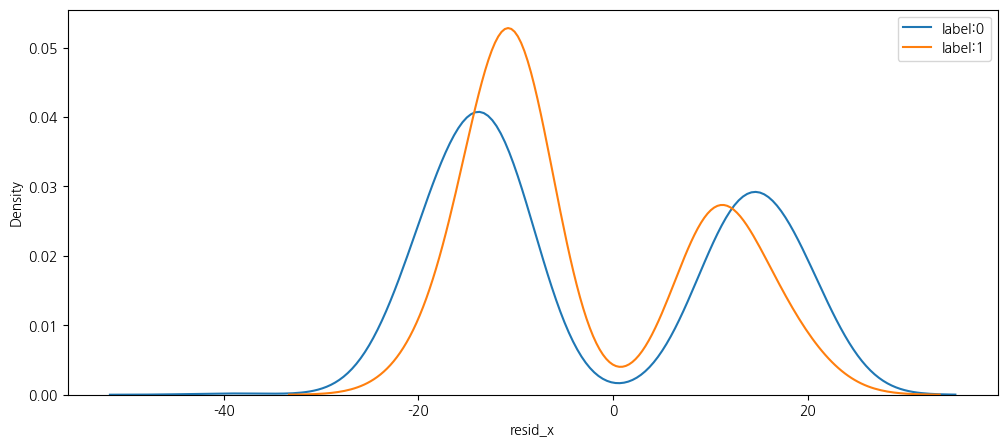

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
for c in mg['cat'].unique():
    sns.kdeplot(data=mg.loc[mg['cat'] == c, 'resid_x'], label=f"label:{c}", ax=ax)
plt.legend()
plt.show()

In [14]:
d2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/31/adp_31_2_v2.csv')

d2.head()

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별
0,ID_4135,169.01,65.47,20041003,2020_11_15,1,2,1,4.4,8.3,남성
1,ID_3289,181.62,69.36,19970725,2014_11_20,0,3,0,4.4,6.9,남성
2,ID_1847,160.89,65.12,20020921,2020_01_28,1,1,1,1.7,9.6,여성
3,ID_4785,162.21,62.28,20020106,2018_09_27,1,4,0,5.1,6.8,남성
4,ID_5693,159.13,54.11,19980708,2015_03_03,0,4,1,0.3,8.5,여성


In [15]:
d2['생년월일'] = pd.to_datetime(d2['생년월일'], format='%Y%m%d')
d2['건강검진일'] = pd.to_datetime(d2['건강검진일'], format='%Y_%m_%d')

d2['만나이'] = ((d2['건강검진일'] - d2['생년월일']).dt.days/365).astype('int')

In [16]:
d2['만나이'].value_counts()

만나이
17    3686
16    3115
Name: count, dtype: int64

In [17]:
d2['키'] = d2['키']/100

d2['BMI'] = (d2['weight']/(d2['키'])**2).round(2)

d2['BMI'].head(3)

0    22.92
1    21.03
2    25.16
Name: BMI, dtype: float64

In [18]:
con1 = (d2['성별'] == '남성')&(d2['만나이'] == 17)&(d2['BMI'] >= 21.03)&(d2['BMI'] < 23.21)
con2 = (d2['성별'] == '여성')&(d2['만나이'] == 17)&(d2['BMI'] >= 20.03)&(d2['BMI'] < 22.39)
con3 = (d2['성별'] == '남성')&(d2['만나이'] == 16)&(d2['BMI'] >= 21.18)&(d2['BMI'] < 23.45)
con4 = (d2['성별'] == '여성')&(d2['만나이'] == 16)&(d2['BMI'] >= 19.61)&(d2['BMI'] < 21.74)

d2['con'] = np.where(con1|con2|con3|con4, 1, 0)

cr = pd.crosstab(d2['만나이'], d2['con'])

display(cr)

con,0,1
만나이,,
16,1086,2029
17,1722,1964


In [27]:
# d2.drop(columns=['ID', '생년월일', '건강검진일'], inplace=True)

In [48]:
c_cols = ['공학여부', '채소섭취정도', '아침식사여부']
d2[c_cols] = d2[c_cols].astype('O')
n_cols = d2.select_dtypes('number').columns[:-1]

In [52]:
fmr = 'con~'+'+'.join(n_cols)

for c in c_cols:
    fmr += '+C('+c+')'

print(f"{fmr}")

con~키+weight+일주일운동시간+수면시간+만나이+BMI+C(공학여부)+C(채소섭취정도)+C(아침식사여부)


In [53]:
# 다음은 로지스틱 회귀

from statsmodels.api import GLM, families

m = GLM.from_formula(fmr, data=d2, family=families.Binomial()).fit()

print(m.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    con   No. Observations:                 6801
Model:                            GLM   Df Residuals:                     6788
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4298.1
Date:                Sun, 19 Oct 2025   Deviance:                       8596.1
Time:                        16:38:25   Pearson chi2:                 7.41e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.08774
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        157.6756      7.650     20.

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
n = m.model.exog_names
vif['name'] = n
vif['vif'] = [variance_inflation_factor(m.model.exog, i) for i in range(len(n))]

display(vif[1:])

,name,vif
1,C(공학여부)[T.1],1.001443
2,C(채소섭취정도)[T.1],1.635187
3,C(채소섭취정도)[T.2],1.657433
4,C(채소섭취정도)[T.3],1.648338
5,C(채소섭취정도)[T.4],1.649637
6,C(아침식사여부)[T.1],1.002196
7,키,174.635748
8,weight,267.868060
9,일주일운동시간,1.002049
10,수면시간,1.001819


In [60]:
coef = m.params[m.pvalues < 0.05].to_frame()

coef.columns = ['coef']

coef = coef.sort_values(by='coef', ascending=False)

In [62]:
np.exp(coef.sort_values(by='coef', ascending=False))

,coef
Intercept,3.003564e+68
weight,3.640457e+00
C(채소섭취정도)[T.1],1.217299e+00
C(공학여부)[T.1],1.109312e+00
수면시간,1.050835e+00
만나이,5.997284e-01
BMI,2.975640e-02
키,4.234584e-40


In [ ]:
pred = np.where(m.predict(d2) > 0.5, 1, 0)

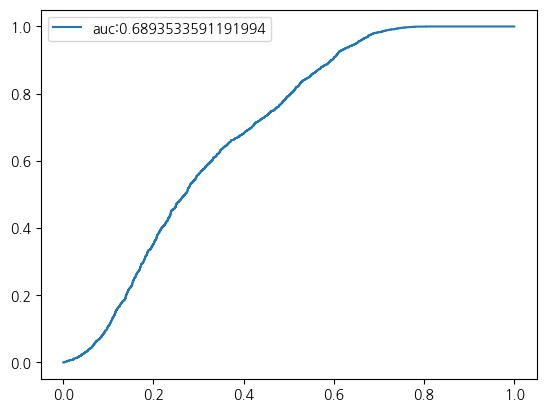

In [64]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
# 일단 1차원 proba로 결과가 들어가야 함
# 무조건 fpr 먼저
proba = m.predict(d2) #statsmodel.api.GLM 결과, 1차원

#1차원용
fpr, tpr, thres = roc_curve(d2['con'].tolist(), proba)
ac = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'auc:{ac}')
plt.legend()
plt.show()

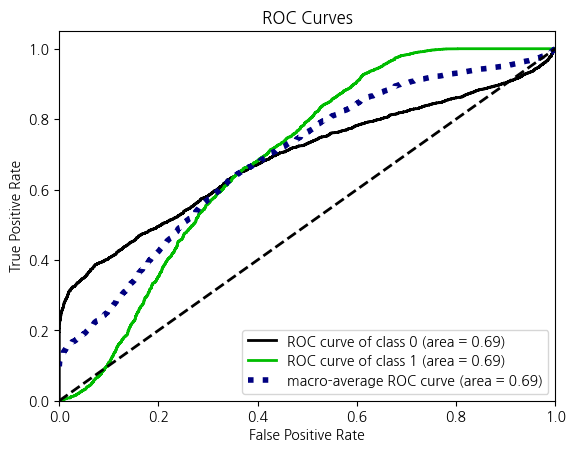

In [73]:
from scikitplot.metrics import plot_roc

# 0, 1순으로 "확률"을 넣어주어야 함(0, 1로 변환하면 안됨!!! 그래서 떨어짐)
proba2 = np.vstack([1-proba, proba]).T

plot_roc(d2['con'].tolist(), proba2, plot_micro=False)
plt.show()

## 머신러닝 2번

In [31]:
d1 = pd.read_csv('../35data/subway.csv')

d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   역번호      10000 non-null  int64 
 1   호선       10000 non-null  int64 
 2   승하차구분    10000 non-null  object
 3   5시_승객수   10000 non-null  int64 
 4   6시_승객수   10000 non-null  int64 
 5   7시_승객수   10000 non-null  int64 
 6   8시_승객수   10000 non-null  int64 
 7   9시_승객수   10000 non-null  int64 
 8   10시_승객수  10000 non-null  int64 
 9   11시_승객수  10000 non-null  int64 
 10  12시_승객수  10000 non-null  int64 
 11  13시_승객수  10000 non-null  int64 
 12  14시_승객수  10000 non-null  int64 
 13  15시_승객수  10000 non-null  int64 
 14  16시_승객수  10000 non-null  int64 
 15  17시_승객수  10000 non-null  int64 
 16  18시_승객수  10000 non-null  int64 
 17  19시_승객수  10000 non-null  int64 
 18  20시_승객수  10000 non-null  int64 
 19  21시_승객수  10000 non-null  int64 
 20  일자       10000 non-null  object
dtypes: int64(19), object(2)
memory usage

In [32]:
d2 = pd.read_csv('../35data/wether.csv')

d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   일자      10000 non-null  object 
 1   시간      10000 non-null  int64  
 2   역번호     10000 non-null  int64  
 3   역이름     10000 non-null  object 
 4   지역      10000 non-null  object 
 5   역_lat   10000 non-null  float64
 6   역_lon   10000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB


In [33]:
d3 = pd.read_csv('../35data/air.csv')

d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   일자       20000 non-null  object 
 1   관측소이름    20000 non-null  object 
 2   관측소_lat  20000 non-null  float64
 3   관측소_lon  20000 non-null  float64
 4   관측소_기온   20000 non-null  float64
 5   관측소_습도   20000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 937.6+ KB


In [34]:
cg = d1.columns[4:-1]

dt1 = d1.groupby(['일자', '역번호'])[cg].sum().reset_index()

In [35]:
dt1 = dt1.melt(id_vars=['일자', '역번호'], var_name='시간', value_name='count')

dt1['시간'] = dt1['시간'].str.replace('시_승객수', '').astype('int64')

dt1.head()

,일자,역번호,시간,count
0,2025-09-01,1,6,16701
1,2025-09-01,2,6,16100
2,2025-09-01,3,6,15293
3,2025-09-01,4,6,16607
4,2025-09-02,1,6,16804


In [36]:
len(dt1)

448

In [37]:
d2.head()

,일자,시간,역번호,역이름,지역,역_lat,역_lon
0,2025-09-01,0,1,서울역,서울,37.56,126.97
1,2025-09-01,0,3,대구역,대구,35.87,128.60
2,2025-09-01,0,4,광주역,광주,35.15,126.85
3,2025-09-01,0,4,광주역,광주,35.15,126.85
4,2025-09-01,0,2,부산역,부산,35.17,129.07


In [38]:
#역별로 위경도가 동일하다는 걸 놓침
tmp = d2.groupby('지역')['역_lat', '역_lon'].mean()

tmp

,역_lat,역_lon
지역,,
광주,35.15,126.85
대구,35.87,128.60
부산,35.17,129.07
서울,37.56,126.97


In [39]:
d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50


In [40]:
cond1 = d3['관측소이름'].str[:2] == '광주'
cond2 = d3['관측소이름'].str[:2] == '대구'
cond3 = d3['관측소이름'].str[:2] == '부산'

d3['s_lat'] = np.where(cond1, 35.15, 
                        np.where(cond2, 35.87, 
                                np.where(cond3, 35.17, 37.56)))

d3['s_lon'] = np.where(cond1, 126.85, 
                        np.where(cond2, 128.60, 
                                np.where(cond3, 129.07, 126.97)))

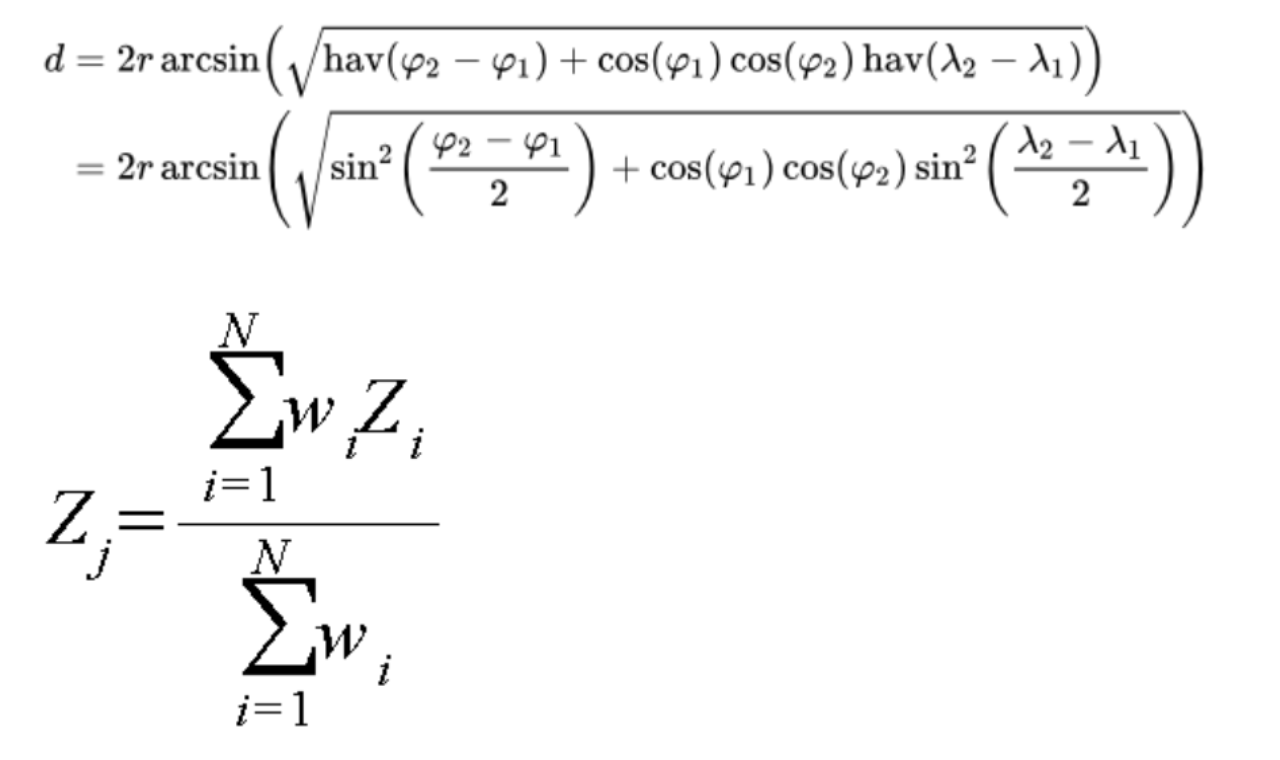

In [41]:
def dist(lat1, lon1, lat2, lon2):
    R = 6371
#     lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2]) #라디안 변환
    sin1 = np.sin((lat2-lat1)/2)**2
    cos1 = np.cos(lat1)
    cos2 = np.cos(lat2)
    sin2 = np.sin((lon2-lon1)/2)**2
    mid = np.sqrt(sin1+cos1*cos2*sin2)
    d = 2*R*np.arcsin(mid)
    return d


dist(35.15, 126.85, 35.1534, 126.8525)

25.365205181388234

In [42]:
d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도,s_lat,s_lon
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72,35.87,128.60
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27,35.17,129.07
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82,37.56,126.97
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86,35.15,126.85
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50,35.15,126.85


In [43]:
d3['dist'] = d3.apply(lambda row: dist(row['s_lat'], row['s_lon'], row['관측소_lat'], row['관측소_lon']), axis=1)

d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도,s_lat,s_lon,dist
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72,35.87,128.60,16.156597
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27,35.17,129.07,18.927208
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82,37.56,126.97,20.624677
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86,35.15,126.85,25.365205
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50,35.15,126.85,25.365205


In [44]:
def ch_z(d, z):
    w = 1/d
    total_w = w.sum()
    up = total_w*z
    rs = up/total_w
    return rs

c_cols = ['관측소_기온', '관측소_습도']

for c in c_cols:
    new_c = 'n' + c.replace('관측소_', '')
    d3[new_c] = ch_z(d3['dist'], d3[c])

In [45]:
d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도,s_lat,s_lon,dist,n기온,n습도
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72,35.87,128.60,16.156597,24.40,50.72
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27,35.17,129.07,18.927208,18.88,53.27
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82,37.56,126.97,20.624677,20.51,87.82
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86,35.15,126.85,25.365205,16.07,46.86
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50,35.15,126.85,25.365205,22.00,41.50


In [46]:
d3['지역'] = d3['관측소이름'].str.replace('관측소', '')

In [47]:
mg = pd.merge(d2, d3[['일자', '지역', 'n기온', 'n습도']], on=['일자', '지역'], how='left')

In [48]:
mg.head()

,일자,시간,역번호,역이름,지역,역_lat,역_lon,n기온,n습도
0,2025-09-01,0,1,서울역,서울,37.56,126.97,20.51,87.82
1,2025-09-01,0,1,서울역,서울,37.56,126.97,26.94,72.71
2,2025-09-01,0,1,서울역,서울,37.56,126.97,13.87,87.25
3,2025-09-01,0,1,서울역,서울,37.56,126.97,17.71,42.44
4,2025-09-01,0,1,서울역,서울,37.56,126.97,19.60,48.03


In [49]:
train = pd.merge(mg, dt1, on=['일자', '시간', '역번호'], how='inner')

train.head()

,일자,시간,역번호,역이름,지역,역_lat,역_lon,n기온,n습도,count
0,2025-09-01,6,1,서울역,서울,37.56,126.97,20.51,87.82,16701
1,2025-09-01,6,1,서울역,서울,37.56,126.97,26.94,72.71,16701
2,2025-09-01,6,1,서울역,서울,37.56,126.97,13.87,87.25,16701
3,2025-09-01,6,1,서울역,서울,37.56,126.97,17.71,42.44,16701
4,2025-09-01,6,1,서울역,서울,37.56,126.97,19.60,48.03,16701


In [50]:
#어휴 망했다...

n_cols = train.select_dtypes('number').columns
c_cols = train.select_dtypes('O').columns[1:]

print("<<통계량>>")
display(train[n_cols].describe().T)
display(train[c_cols].describe().T)

<<통계량>>


,count,mean,std,min,25%,50%,75%,max
시간,40626.0,13.530301,4.595428,6.00,10.00,14.00,17.00,21.00
역번호,40626.0,2.514498,1.069590,1.00,2.00,2.00,3.00,4.00
역_lat,40626.0,35.822551,0.930016,35.15,35.17,35.17,35.87,37.56
역_lon,40626.0,127.990661,0.992141,126.85,126.97,128.60,129.07,129.07
n기온,40626.0,19.970051,5.244545,4.83,16.56,19.91,23.33,32.61
n습도,40626.0,65.308147,14.118124,40.53,53.61,66.68,77.16,89.66
count,40626.0,29573.815094,8339.846369,14569.00,22566.00,29675.00,36543.00,46211.00


,count,unique,top,freq
역이름,40626,4,부산역,12829
지역,40626,4,부산,12829


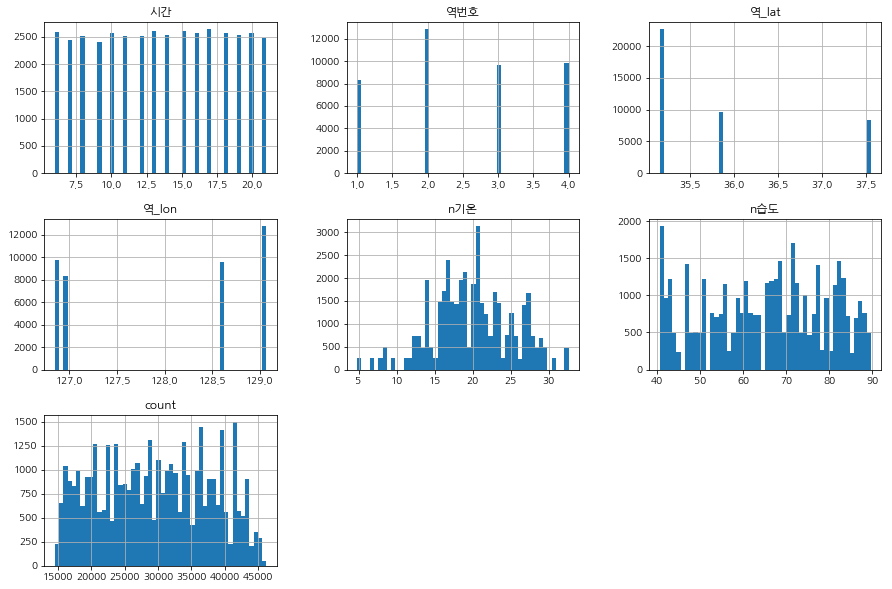

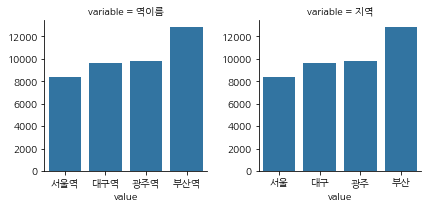

In [51]:
train[n_cols].hist(bins=50, figsize=(15, 10))
plt.show()

mt = train[c_cols].melt()
g = sns.FacetGrid(mt, col='variable', sharex=False, sharey=False, col_wrap=4)
g.map(sns.countplot, 'value')
plt.show()

In [52]:
cg = ['시간', '역번호']

train[cg] = train[cg].astype('O')

In [53]:
size = int(len(train)*0.8)
train, test = train[:size], train.iloc[size:]

print(train.shape, test.shape)

(32500, 10) (8126, 10)


In [54]:
train_x, train_y = train[['시간', '역번호', '역이름', 'n기온', 'n습도']], train['count']
test_x, test_y = test[['시간', '역번호', '역이름', 'n기온', 'n습도']], test['count']

In [55]:
n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

pre = make_column_transformer(
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf = Pipeline([
    ('pre', pre), 
    ('cl', RandomForestRegressor(random_state=42))
])

rf.fit(train_x, train_y)

rs = pd.DataFrame(columns=['data', 'r2', 'rmse'])

d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

for n, x, y in d_list:
    pred = rf.predict(x)
    r2 = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    rs.loc[len(rs)] = [n, r2, rmse]
display(rs)

,data,r2,rmse
0,train,1.000000,1.314858
1,test,0.918993,2385.751239


In [56]:
2385.751239/(test_y.max() - test_y.min())*100

7.964450806209314

랜덤포레스트 학습 결과 rmse에서 과적합이 발생한 것 같지만 종속변수 범위를 보았을 때, 범위 대비 약 8%의 표준오차를 가지며,  
r2 설명력이 거의 1에 가까운 값을 가지므로 우수한 모델이라고 할 수 있다.   

r2 설명력: ssr/sst로 종속변수의 분산을 약 92% 설명  
rmse: mse의 제곱근으로 종속변수와 단위가 같아 표준오차 추정 가능  

//끝.